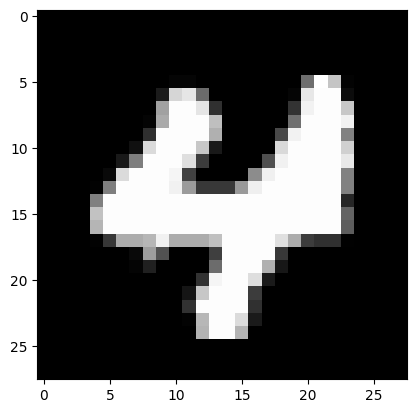

Număr sub-intervale:  3 -> Acuratețe: 83.80%
Număr sub-intervale:  5 -> Acuratețe: 84.00%
Număr sub-intervale:  7 -> Acuratețe: 84.20%
Număr sub-intervale:  9 -> Acuratețe: 84.20%
Număr sub-intervale: 11 -> Acuratețe: 84.20%

Cel mai bun număr de sub-intervale: 7 (Acuratețe: 84.20%)


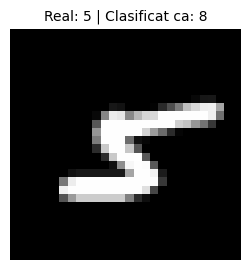

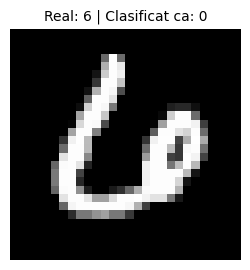

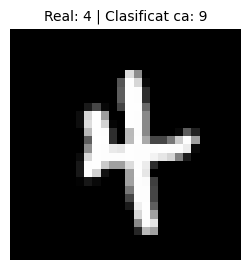

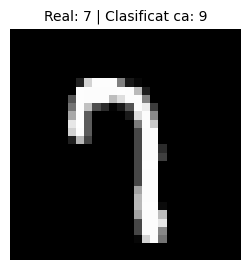

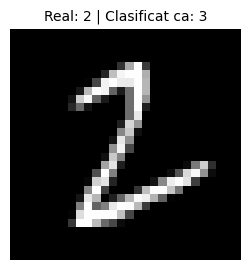

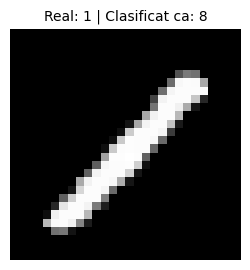

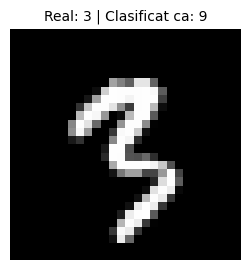

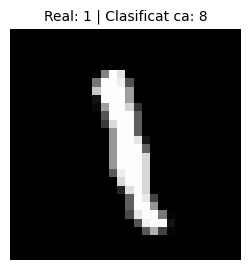

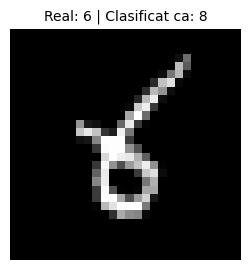

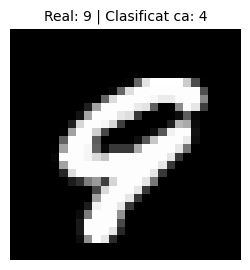

Matricea de confuzie calculată:
[[51  0  0  0  0  0  1  0  1  0]
 [ 0 48  0  0  0  0  1  0  3  0]
 [ 2  0 51  1  1  0  1  1  1  0]
 [ 0  0  1 49  0  0  0  0  0  3]
 [ 0  0  0  0 34  0  0  0  2 10]
 [ 1  0  1  9  0 34  1  0  5  1]
 [ 1  1  0  0  1  0 44  0  1  0]
 [ 0  1  0  0  2  0  0 41  0  6]
 [ 0  1  3  3  1  1  1  1 34  1]
 [ 0  0  1  1  5  0  0  0  0 35]]


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB

train_images = np.loadtxt('data/train_images.txt')
train_labels = np.loadtxt('data/train_labels.txt').astype(int)
test_images = np.loadtxt('data/test_images.txt')
test_labels = np.loadtxt('data/test_labels.txt').astype(int)

image = train_images[0,:]
image = np.reshape(image, (28,28))
# afisarea primei imagini doar asa
plt.imshow(image.astype(np.uint8), cmap='gray')
plt.show()

bins = np.linspace(0,255,5)

def values_to_bins(x, bins_number):
    x_disc = np.digitize(x, bins_number) - 1
    return np.clip(x_disc, 0, len(bins_number) - 2)

bin_options = [3, 5, 7, 9, 11]
best_accuracy = -1
best_num_bins = None
best_clf = None
best_X_test_discretized = None

for num_bins in bin_options:
    bins = np.linspace(0, 255, num_bins + 1)
    X_train_bins = values_to_bins(train_images, bins)
    X_test_bins = values_to_bins(test_images, bins)

    clf = MultinomialNB()
    clf.fit(X_train_bins, train_labels)

    accuracy = clf.score(X_test_bins, test_labels)
    print(f"Număr sub-intervale: {num_bins:2d} -> Acuratețe: {accuracy * 100:.2f}%")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_num_bins = num_bins
        best_clf = clf
        best_X_test_discretized = X_test_bins

print(f"\nCel mai bun număr de sub-intervale: {best_num_bins} (Acuratețe: {best_accuracy * 100:.2f}%)")

# iau predictiile
predictions = best_clf.predict(best_X_test_discretized)
# iau indicii unde au fost misclasari
misclassified_indices = np.where(predictions != test_labels)[0]

# maxim 10
num_to_show = min(10, len(misclassified_indices))

for i in range(num_to_show):
    idx = misclassified_indices[i]

    # reshape imaginea din test ca 28x28
    img_2d = np.reshape(test_images[idx, :], (28, 28))

    # iau labelurile ca sa stiu ce era si ce a ghicit asta prost
    predicted_label = predictions[idx]
    true_label = test_labels[idx]

    plt.figure(figsize=(3, 3))
    plt.imshow(img_2d.astype(np.uint8), cmap='gray')
    plt.title(f"Real: {true_label} | Clasificat ca: {predicted_label}", fontsize=10)
    plt.axis('off')
    plt.show()


def confusion_matrix(y_true, y_pred):
    num_classes = 10

    cm = np.zeros((num_classes, num_classes), dtype=int)
    for true_label, pred_label in zip(y_true, y_pred):
        cm[true_label, pred_label] += 1

    return cm

y_pred_optim = best_clf.predict(best_X_test_discretized)
matrice_confuzie = confusion_matrix(test_labels, y_pred_optim)

print("Matricea de confuzie calculată:")
print(matrice_confuzie)